# 04 · Four Yankees-developed hitters

A descriptive look at Ben Rice, Anthony Volpe, Jasson Dominguez, and Oswald Peraza: how each arrived, what his minor-league line looked like, and how his MLB production and plate discipline have moved season by season through 2026.

Public data shows outcomes and approach. It does not show health, coaching plans, or internal evaluations, so this notebook describes rather than explains. Official facts (draft slot, minor-league lines, roster moves) come from the MLB Stats API; MLB rates come from Statcast using the definitions in notebook 02.

In [1]:
import sys
import warnings

warnings.filterwarnings("ignore", message=".*urllib3.*")
sys.path.insert(0, "../src")

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

FIG_DIR = Path("../outputs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR = Path("../outputs/data")
DATA_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.precision", 3)

import json

import requests

from yanks_analytics.data.prospects import MILB_STATS
from yanks_analytics.data.statcast import CACHE_DIR, load_seasons
from yanks_analytics.features.season import season_table

PLAYERS = {"Ben Rice": 700250, "Anthony Volpe": 683011,
           "Jasson Dominguez": 691176, "Oswald Peraza": 672724}
COLORS = {"Ben Rice": "#0c2340", "Anthony Volpe": "#2e86c1",
          "Jasson Dominguez": "#7f8c8d", "Oswald Peraza": "#c0392b"}

def mlb_api(path: str, cache_name: str, **params) -> dict:
    """GET from the MLB Stats API, cached as JSON so reruns are reproducible."""
    cache = CACHE_DIR / f"mlbapi_{cache_name}.json"
    if not cache.exists():
        response = requests.get(f"https://statsapi.mlb.com/api/v1/{path}", params=params, timeout=30)
        response.raise_for_status()
        cache.write_text(json.dumps(response.json()))
    return json.loads(cache.read_text())

## How they arrived

In [2]:
people = mlb_api("people", "case_study_people",
                 personIds=",".join(map(str, PLAYERS.values())), hydrate="draft")["people"]
rows = []
for p in people:
    yankees_draft = [d for d in p.get("drafts", []) if d.get("team", {}).get("name") == "New York Yankees"]
    if yankees_draft:
        d = yankees_draft[-1]
        acquired = f"{d['year']} draft, round {d['pickRound']}, pick {d['pickNumber']}"
    else:
        acquired = "International amateur signing"
    rows.append({"player": p["fullName"], "bats": p["batSide"]["code"],
                 "acquired": acquired, "MLB debut": p["mlbDebutDate"]})
pd.DataFrame(rows).set_index("player")

,bats,acquired,MLB debut
player,,,
Ben Rice,L,"2021 draft, round 12, pick 363",2024-06-18
Anthony Volpe,R,"2019 draft, round 1, pick 30",2023-03-30
Jasson Domínguez,S,International amateur signing,2023-09-01
Oswald Peraza,R,International amateur signing,2022-09-02


## Minor-league lines

Season totals across levels (MLB Stats API). Only the seasons leading into each player's MLB debut are shown.

In [3]:
milb = pd.DataFrame([
    {"player": name, "season": season, **line}
    for name, seasons in MILB_STATS.items() if name in PLAYERS
    for season, line in seasons.items()
]).set_index(["player", "season"])
milb[["level", "g", "pa", "avg", "obp", "slg", "hr", "bb_pct", "k_pct"]].style.format(
    {"avg": "{:.3f}", "obp": "{:.3f}", "slg": "{:.3f}", "bb_pct": "{:.1%}", "k_pct": "{:.1%}"})

## MLB seasons

Regular season only. Rates with fewer than 100 PA in a season are shown but should be read as noise.

In [4]:
pitches = load_seasons(range(2022, 2027))
pitches = pitches[pitches["batter"].isin(PLAYERS.values())]
mlb = season_table(pitches).reset_index()
mlb["player"] = mlb["batter"].map({v: k for k, v in PLAYERS.items()})
mlb = mlb.set_index(["player", "season"]).sort_index()
cols = ["PA", "wOBA", "xwOBA", "chase", "zone_contact", "whiff", "whiff_96plus"]
mlb[cols].to_csv(DATA_DIR / "case_study_mlb_seasons.csv")
mlb[cols].style.format({"PA": "{:.0f}", "wOBA": "{:.3f}", "xwOBA": "{:.3f}", "chase": "{:.1%}",
                        "zone_contact": "{:.1%}", "whiff": "{:.1%}", "whiff_96plus": "{:.1%}"})

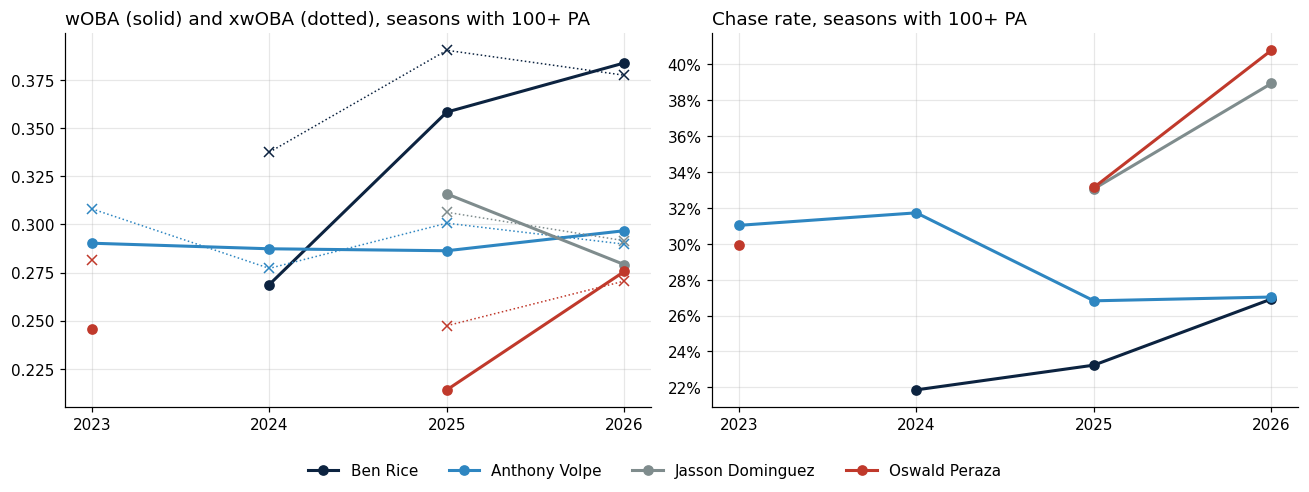

In [5]:
from matplotlib.ticker import MultipleLocator

YEARS = range(2023, 2027)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name in PLAYERS:
    d = mlb.loc[name]
    # Seasons under 100 PA become gaps, so lines never bridge a missing season.
    d = d.where(d["PA"] >= 100).reindex(YEARS)
    axes[0].plot(d.index, d["wOBA"], marker="o", color=COLORS[name], label=name, linewidth=2)
    axes[0].plot(d.index, d["xwOBA"], marker="x", color=COLORS[name], linestyle=":", linewidth=1)
    axes[1].plot(d.index, d["chase"], marker="o", color=COLORS[name], label=name, linewidth=2)
axes[0].set_title("wOBA (solid) and xwOBA (dotted), seasons with 100+ PA", loc="left")
axes[1].set_title("Chase rate, seasons with 100+ PA", loc="left")
axes[1].yaxis.set_major_locator(MultipleLocator(0.02))
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
for ax in axes:
    ax.set_xticks(YEARS)
fig.tight_layout(rect=(0, 0.08, 1, 1))
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, frameon=False)
fig.savefig(FIG_DIR / "case_study_seasons.png", dpi=150, bbox_inches="tight")
plt.show()

## Where they sit in the cohort

From notebooks 01 and 03: wOBA over the first 600 MLB PA, and the early-window read for players with 850+ PA.

In [6]:
outcomes = pd.read_csv(DATA_DIR / "cohort_outcomes.csv", index_col="mlbam_id")
cohort_rank = outcomes["wOBA_first600"].where(outcomes["label"] != "insufficient").rank(ascending=False)
summary = outcomes.loc[list(PLAYERS.values()), ["name", "career_PA", "wOBA_first600", "label"]]
summary["rank of 39 labeled"] = cohort_rank.loc[list(PLAYERS.values())].astype(int)
summary.set_index("name")

,career_PA,wOBA_first600,label,rank of 39 labeled
name,,,,
Ben Rice,1369.0,0.330,solid,12
Anthony Volpe,2124.0,0.290,disappointing,29
Jasson Dominguez,749.0,0.316,solid,20
Oswald Peraza,892.0,0.263,bust,37


## 2026 roster context

Statcast shows when a player is absent, not why, so absences are read from the official transaction log.

In [7]:
KEEP = ("Optioned", "Recalled", "Status Change", "Assigned")
rows = []
for name, pid in PLAYERS.items():
    log = mlb_api("transactions", f"transactions_{pid}_2026", playerId=pid,
                  startDate="2026-01-01", endDate="2026-09-29")["transactions"]
    for t in log:
        if t.get("typeDesc") in KEEP:
            rows.append({"player": name, "date": t["date"], "type": t["typeDesc"],
                         "description": t["description"]})
moves = pd.DataFrame(rows).drop_duplicates().sort_values(["player", "date"])
moves.to_csv(DATA_DIR / "case_study_2026_transactions.csv", index=False)
with pd.option_context("display.max_colwidth", 140):
    display(moves.set_index(["player", "date"]))

type  \
player           date                        
Anthony Volpe    2026-03-25  Status Change   
                 2026-04-14       Assigned   
                 2026-04-21       Assigned   
                 2026-04-28       Assigned   
                 2026-05-04       Optioned   
                 2026-05-12       Recalled   
                 2026-08-04       Optioned   
                 2026-09-10       Recalled   
Ben Rice         2026-07-13  Status Change   
Jasson Dominguez 2026-03-20  Status Change   
                 2026-03-20       Optioned   
                 2026-04-27       Recalled   
                 2026-05-08  Status Change   
                 2026-06-05       Assigned   
                 2026-06-13  Status Change   
                 2026-08-04       Optioned   
                 2026-09-05       Recalled   
                 2026-09-11       Optioned   
                 2026-09-28       Recalled   
Oswald Peraza    2026-04-16  Status Change   

                                                                                                                                                    description  
player           date                                                                                                                                            
Anthony Volpe    2026-03-25  New York Yankees placed SS Anthony Volpe on the 10-day injured list retroactive to March 22, 2026. Left shoulder surgery recovery.  
                 2026-04-14                                                  New York Yankees sent SS Anthony Volpe on a rehab assignment to Somerset Patriots.  
                 2026-04-21                                   New York Yankees sent SS Anthony Volpe on a rehab assignment to Scranton/Wilkes-Barre RailRiders.  
                 2026-04-28                                                  New York Yankees sent SS Anthony Volpe on a rehab assignment to Somerset Patriots.  
                 2026-05-04                                                     New York Yankees optioned SS Anthony Volpe to Scranton/Wilkes-Barre RailRiders.  
                 2026-05-12                                                   New York Yankees recalled SS Anthony Volpe from Scranton/Wilkes-Barre RailRiders.  
                 2026-08-04                                                     New York Yankees optioned SS Anthony Volpe to Scranton/Wilkes-Barre RailRiders.  
                 2026-09-10                                                   New York Yankees recalled SS Anthony Volpe from Scranton/Wilkes-Barre RailRiders.  
Ben Rice         2026-07-13                                                                                    American League All-Stars activated 1B Ben Rice.  
Jasson Dominguez 2026-03-20                                                                     Scranton/Wilkes-Barre RailRiders activated LF Jasson Domínguez.  
                 2026-03-20                                                  New York Yankees optioned LF Jasson Domínguez to Scranton/Wilkes-Barre RailRiders.  
                 2026-04-27                                                New York Yankees recalled LF Jasson Domínguez from Scranton/Wilkes-Barre RailRiders.  
                 2026-05-08                              New York Yankees placed LF Jasson Domínguez on the 10-day injured list. Left shoulder AC joint sprain.  
                 2026-06-05                                New York Yankees sent LF Jasson Domínguez on a rehab assignment to Scranton/Wilkes-Barre RailRiders.  
                 2026-06-13                                                        New York Yankees activated LF Jasson Domínguez from the 10-day injured list.  
                 2026-08-04                                                  New York Yankees optioned RF Jasson Domínguez to Scranton/Wilkes-Barre RailRiders.  
                 2026-09-05                                                New York Yankees recalled RF Jasso

Oswald Peraza was traded to the Los Angeles Angels on July 31, 2025, so his 2026 season was played for the Angels.

## Findings

- **Ben Rice's contact quality led his results.** In his 178-PA debut in 2024 his xwOBA (.338) ran well ahead of his wOBA (.269). His wOBA then caught up: .358 in 2025 and .384 in 2026, when he made the American League All-Star team. His chase rate has stayed between 22% and 27%.
- **Anthony Volpe's production has been steady at a level below where his prospect profile pointed.** His wOBA has been between .286 and .297 in all four seasons, with xwOBA between .277 and .308. His chase rate fell from 31–32% in 2023–24 to 27% in 2025–26 without a matching change in output, which fits notebook 02: discipline gains alone rarely move production. In 2026 he opened on the injured list after left shoulder surgery and was optioned twice.
- **Jasson Dominguez's sample is still short and interrupted.** His one full season (2025) produced a .316 wOBA in 428 PA. In 2026 he had 221 PA around a shoulder AC joint sprain (May 8 to June 13) and two option assignments, with a career-high 38.9% chase rate. His first-600-PA wOBA (.316) is the cohort's 20th best of 39.
- **Oswald Peraza** reached 600 MLB PA only in 2026, with a .263 wOBA over that span, 37th of 39.

These are descriptions. Public data cannot separate development choices from health, role, opportunity, or ordinary variance, and this notebook does not attempt to.